<a href="https://colab.research.google.com/github/kalliyathhana-svg/NorthStar-Urban-Mobility/blob/main/RAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c("sqldf", "ggplot2", "dplyr", "lubridate", "scales"))
library(sqldf)
library(ggplot2)
library(dplyr)
library(lubridate)
library(scales)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [2]:
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE)
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE)
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE)
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE)
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE)
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE)
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE)
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE)

# Quick sanity check
cat("Rows loaded:\n")
cat("  customers :", nrow(customers),  "\n")
cat("  orders    :", nrow(orders),     "\n")
cat("  deliveries:", nrow(deliveries), "\n")
cat("  complaints:", nrow(complaints), "\n")

Rows loaded:
  customers : 650 
  orders    : 1250 
  deliveries: 950 
  complaints: 320 



── Query 1: Delivery status breakdown ──
  delivery_status total   pct
1          OnTime   616 64.84
2         Delayed   202 21.26
3          Failed   132 13.89


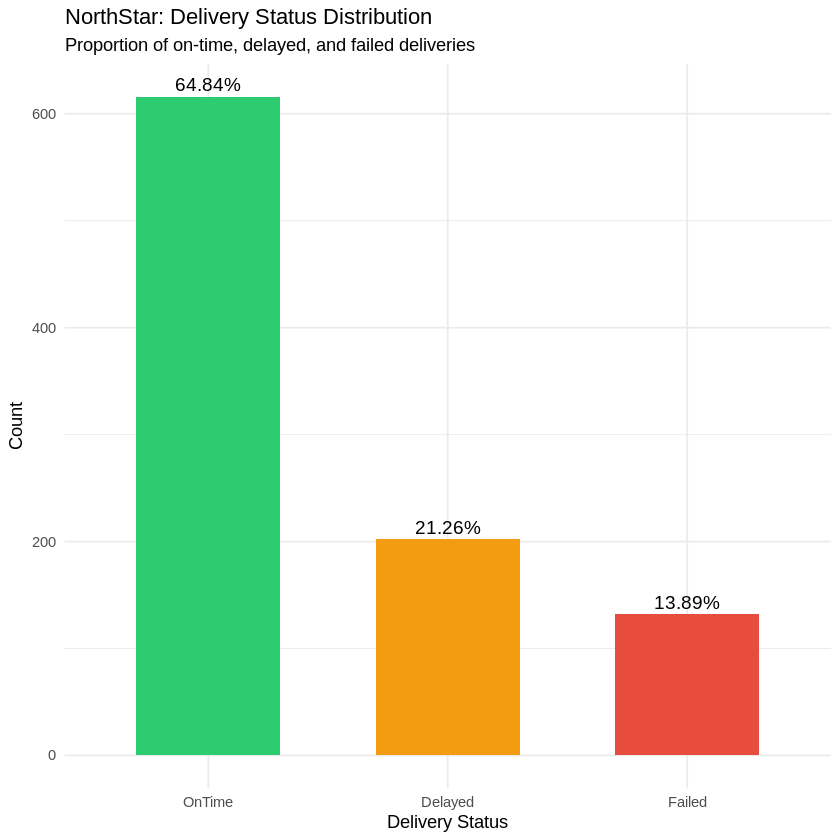

In [3]:
q1 <- sqldf("
  SELECT
    delivery_status,
    COUNT(*)                                      AS total,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 2) AS pct
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total DESC
")

cat("\n── Query 1: Delivery status breakdown ──\n")
print(q1)

# Visualise
ggplot(q1, aes(x = reorder(delivery_status, -total), y = total,
               fill = delivery_status)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(pct, "%")), vjust = -0.4, size = 4) +
  scale_fill_manual(values = c("OnTime" = "#2ecc71",
                                "Delayed" = "#f39c12",
                                "Failed"  = "#e74c3c")) +
  labs(title = "NorthStar: Delivery Status Distribution",
       subtitle = "Proportion of on-time, delayed, and failed deliveries",
       x = "Delivery Status", y = "Count") +
  theme_minimal() +
  theme(legend.position = "none")


── Query 2: Failure rate by pickup zone ──
   pickup_zone total_deliveries failed delayed failure_rate_pct
1    RiverSide               66     14      12            21.21
2      Central               55     11      11            20.00
3      CENTRAL               55     11      16            20.00
4        North               37      7       6            18.92
5          Ctr               64     11      24            17.19
6        north               52      8       6            15.38
7        NORTH               46      7       9            15.22
8         EAST               78     11      14            14.10
9         West               51      7       8            13.73
10       South               83     10      15            12.05
11     Airport               67      8      18            11.94
12        WEST               63      7      13            11.11
13        East               78      8      17            10.26
14     AIRPORT               46      4      13             8

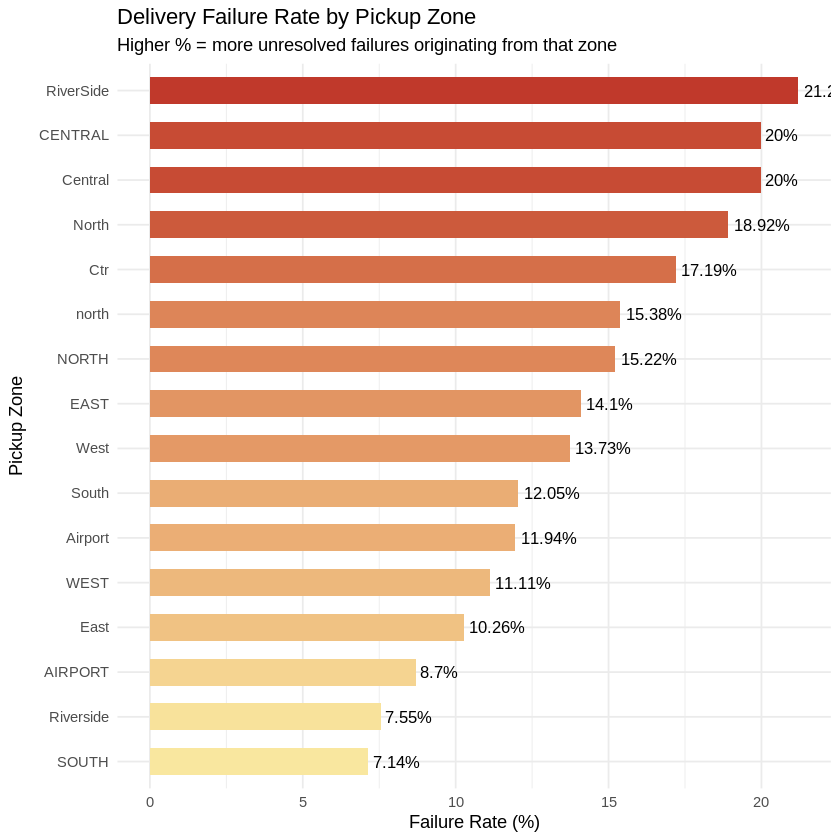

In [4]:
q2 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(d.delivery_id)                          AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)  AS failed,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0
      / COUNT(d.delivery_id), 2)                  AS failure_rate_pct
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")

cat("\n── Query 2: Failure rate by pickup zone ──\n")
print(q2)

ggplot(q2, aes(x = reorder(pickup_zone, failure_rate_pct),
               y = failure_rate_pct, fill = failure_rate_pct)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")),
            hjust = -0.1, size = 3.5) +
  coord_flip() +
  scale_fill_gradient(low = "#f9e79f", high = "#c0392b") +
  labs(title = "Delivery Failure Rate by Pickup Zone",
       subtitle = "Higher % = more unresolved failures originating from that zone",
       x = "Pickup Zone", y = "Failure Rate (%)") +
  theme_minimal() +
  theme(legend.position = "none")


── Query 3: Complaints by type and severity ──
      complaint_type severity total avg_compensation avg_resolution_days
1              Delay   Medium    56            18.21                5.96
2       MissedPickup   Medium    37            17.91                6.16
3    DriverBehaviour   Medium    31            15.88                5.42
4              Delay      Low    27             8.16                6.48
5           AppIssue   Medium    25            16.11                7.36
6              Delay     High    18            36.54               12.44
7    DriverBehaviour     High    16            38.39               13.75
8       MissedPickup     High    16            43.07               11.56
9           AppIssue      Low    15            13.25                6.07
10          AppIssue     High    13            34.05               13.92
11 SupportExperience   Medium    12            18.68                6.17
12      MissedPickup      Low    11             8.14                6.91
13 

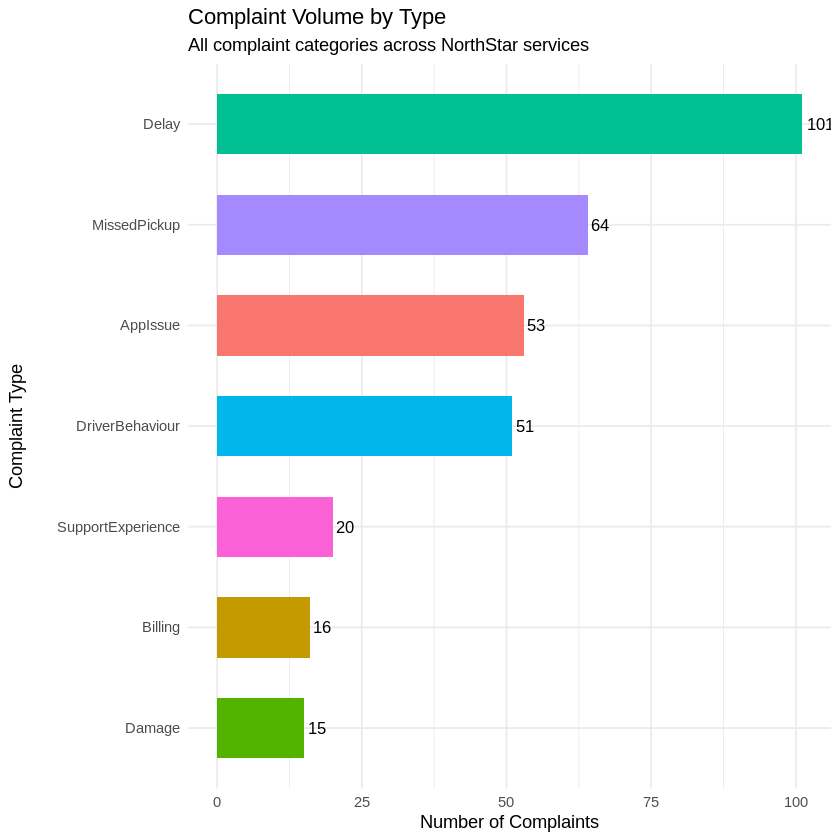

In [5]:
q3 <- sqldf("
  SELECT
    complaint_type,
    severity,
    COUNT(*)                    AS total,
    ROUND(AVG(compensation_amount), 2) AS avg_compensation,
    ROUND(AVG(resolution_days), 2)     AS avg_resolution_days
  FROM complaints
  GROUP BY complaint_type, severity
  ORDER BY total DESC
")

cat("\n── Query 3: Complaints by type and severity ──\n")
print(q3)

# Aggregate for chart
q3_agg <- sqldf("
  SELECT complaint_type, COUNT(*) AS total
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total DESC
")

ggplot(q3_agg, aes(x = reorder(complaint_type, total), y = total,
                   fill = complaint_type)) +
  geom_bar(stat = "identity", width = 0.6) +
  geom_text(aes(label = total), hjust = -0.2, size = 3.5) +
  coord_flip() +
  labs(title = "Complaint Volume by Type",
       subtitle = "All complaint categories across NorthStar services",
       x = "Complaint Type", y = "Number of Complaints") +
  theme_minimal() +
  theme(legend.position = "none")


── Query 4: Top drivers by manual route overrides ──
   driver_id base_zone employment_type avg_rating total_deliveries
1       D127   CENTRAL        FullTime       4.19                6
2       D130      WEST        FullTime       3.64                8
3       D087     north        Contract       4.43               12
4       D131     SOUTH        FullTime       4.26                9
5       D108     South        FullTime       4.33               11
6       D105 RiverSide        Contract       3.71                7
7       D069     NORTH        PartTime       5.00                7
8       D028     North        FullTime       4.07                7
9       D017      EAST        PartTime       4.34               10
10      D104      WEST        FullTime       3.45                7
11      D026     NORTH        PartTime       3.15               11
12      D008     SOUTH        FullTime       3.88                8
13      D133     South        Contract       3.99               12
14      

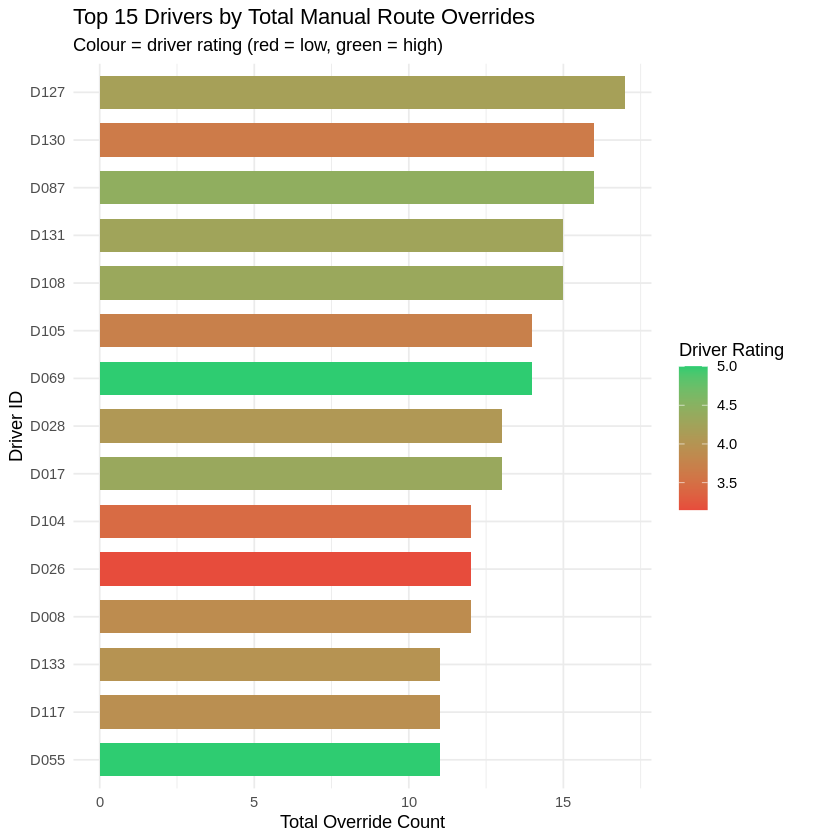

In [6]:
q4 <- sqldf("
  SELECT
    d.driver_id,
    dr.base_zone,
    dr.employment_type,
    ROUND(dr.driver_rating, 2)          AS avg_rating,
    COUNT(d.delivery_id)                AS total_deliveries,
    SUM(d.manual_route_override_count)  AS total_overrides,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides_per_trip,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 3
  ORDER BY total_overrides DESC
  LIMIT 15
")

cat("\n── Query 4: Top drivers by manual route overrides ──\n")
print(q4)

ggplot(q4, aes(x = reorder(driver_id, total_overrides),
               y = total_overrides, fill = avg_rating)) +
  geom_bar(stat = "identity", width = 0.7) +
  coord_flip() +
  scale_fill_gradient(low = "#e74c3c", high = "#2ecc71",
                      name = "Driver Rating") +
  labs(title = "Top 15 Drivers by Total Manual Route Overrides",
       subtitle = "Colour = driver rating (red = low, green = high)",
       x = "Driver ID", y = "Total Override Count") +
  theme_minimal()


── Query 5: Revenue, cost and margin by service type ──
  service_type deliveries total_revenue total_cost gross_margin avg_order_value
1    Passenger        262      25463.36    3248.56     22214.80           97.19
2       Parcel        230      20735.44    3009.01     17726.43           90.15
3       Retail        224      19444.86    2906.27     16538.59           86.81
4     Business        126      12279.23    1655.91     10623.32           97.45
5      Medical        108       9344.88    1379.48      7965.40           86.53
  avg_cost avg_rating
1    12.40       3.85
2    13.08       3.90
3    12.97       3.87
4    13.14       3.85
5    12.77       3.84


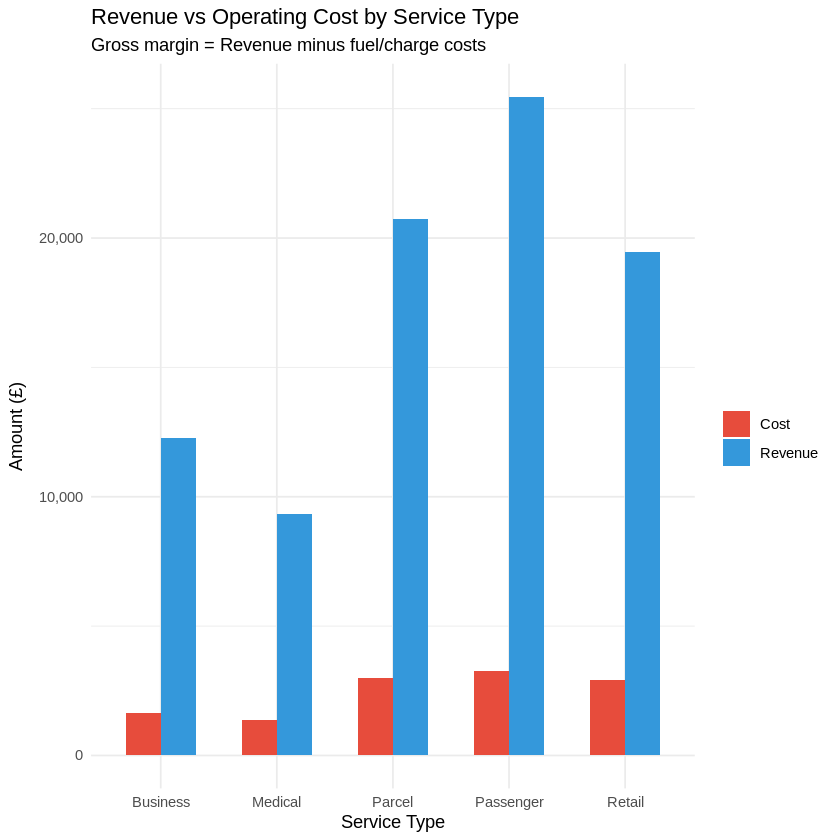

In [7]:
q5 <- sqldf("
  SELECT
    o.service_type,
    COUNT(d.delivery_id)              AS deliveries,
    ROUND(SUM(o.order_value), 2)      AS total_revenue,
    ROUND(SUM(d.fuel_or_charge_cost), 2) AS total_cost,
    ROUND(SUM(o.order_value) - SUM(d.fuel_or_charge_cost), 2) AS gross_margin,
    ROUND(AVG(o.order_value), 2)      AS avg_order_value,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY gross_margin DESC
")

cat("\n── Query 5: Revenue, cost and margin by service type ──\n")
print(q5)

# Reshape for grouped bar
q5_long <- data.frame(
  service_type = rep(q5$service_type, 2),
  metric       = c(rep("Revenue", nrow(q5)), rep("Cost", nrow(q5))),
  value        = c(q5$total_revenue, q5$total_cost)
)

ggplot(q5_long, aes(x = service_type, y = value, fill = metric)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.6) +
  scale_fill_manual(values = c("Revenue" = "#3498db", "Cost" = "#e74c3c")) +
  scale_y_continuous(labels = comma) +
  labs(title = "Revenue vs Operating Cost by Service Type",
       subtitle = "Gross margin = Revenue minus fuel/charge costs",
       x = "Service Type", y = "Amount (£)", fill = "") +
  theme_minimal()


── Query 6: Zone × service type performance matrix ──
   pickup_zone service_type deliveries avg_rating failures delays avg_overrides
1          Ctr       Retail         22       2.89        6      9          0.73
2         EAST    Passenger         24       3.89        5      3          0.67
3    RiverSide       Parcel         17       3.64        4      4          1.12
4         EAST       Parcel         23       3.74        4      5          0.87
5      CENTRAL       Retail         13       3.87        4      3          1.15
6        South    Passenger         28       4.01        4      2          0.50
7      Central    Passenger         20       3.43        3      6          1.55
8        north     Business         12       3.49        3      2          0.92
9      Airport    Passenger         18       3.55        3      6          1.56
10        East       Retail         20       3.59        3      5          0.80
11     Central       Retail         14       3.59        3      2

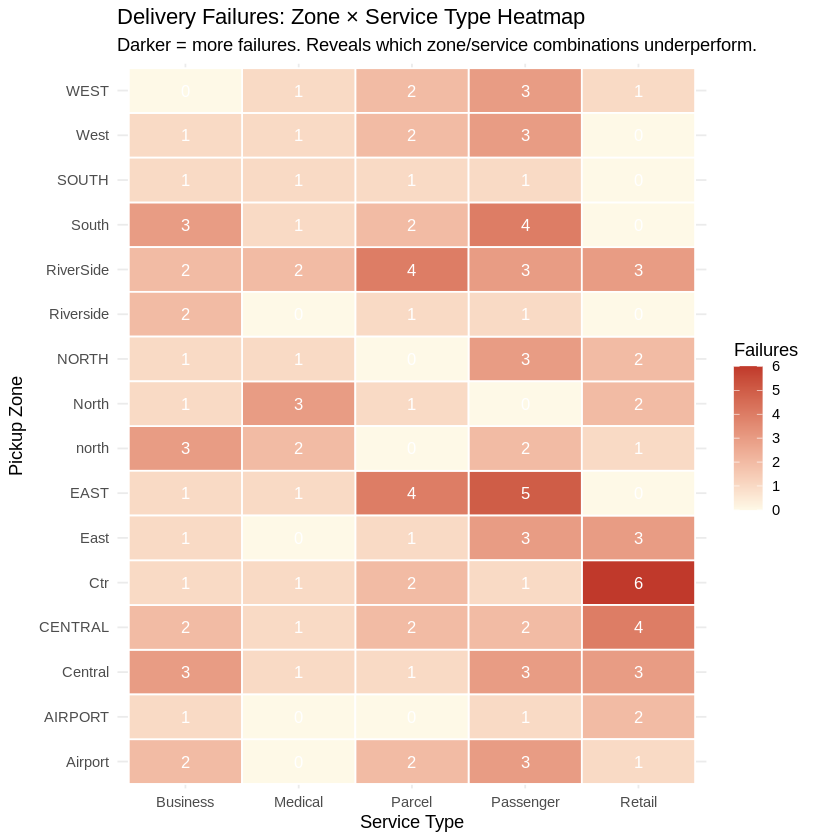

In [8]:
q6 <- sqldf("
  SELECT
    o.pickup_zone,
    o.service_type,
    COUNT(d.delivery_id)                                          AS deliveries,
    ROUND(AVG(d.customer_rating_post_delivery), 2)                AS avg_rating,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failures,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delays,
    ROUND(AVG(d.manual_route_override_count), 2)                  AS avg_overrides,
    ROUND(SUM(o.order_value), 2)                                  AS zone_revenue
  FROM deliveries d
  JOIN orders o     ON d.order_id   = o.order_id
  JOIN customers c  ON o.customer_id = c.customer_id
  GROUP BY o.pickup_zone, o.service_type
  ORDER BY failures DESC, avg_rating ASC
")

cat("\n── Query 6: Zone × service type performance matrix ──\n")
print(q6)

# Heatmap of failure count by zone and service type
ggplot(q6, aes(x = service_type, y = pickup_zone, fill = failures)) +
  geom_tile(colour = "white", linewidth = 0.5) +
  geom_text(aes(label = failures), size = 3.5, colour = "white") +
  scale_fill_gradient(low = "#fef9e7", high = "#c0392b", name = "Failures") +
  labs(title = "Delivery Failures: Zone × Service Type Heatmap",
       subtitle = "Darker = more failures. Reveals which zone/service combinations underperform.",
       x = "Service Type", y = "Pickup Zone") +
  theme_minimal()


── Query 7: Customers with 2+ complaints ──
   customer_id home_zone customer_type loyalty_score complaint_count
1        C0368     North      Consumer          49.5               4
2        C0421   CENTRAL      Consumer          59.0               3
3        C0573   AIRPORT           SME          57.3               3
4        C0242      East      Consumer          83.8               3
5        C0282 RiverSide      Consumer          71.4               3
6        C0545     SOUTH      Consumer          66.9               3
7        C0372      West      Consumer          26.2               3
8        C0191     North      Consumer          58.9               3
9        C0172     north      Consumer          75.4               3
10       C0142     SOUTH      Consumer          47.0               3
11       C0110      EAST      Consumer            NA               3
12       C0626     SOUTH      Consumer          61.6               3
13       C0351   CENTRAL    Enterprise          48.6      

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


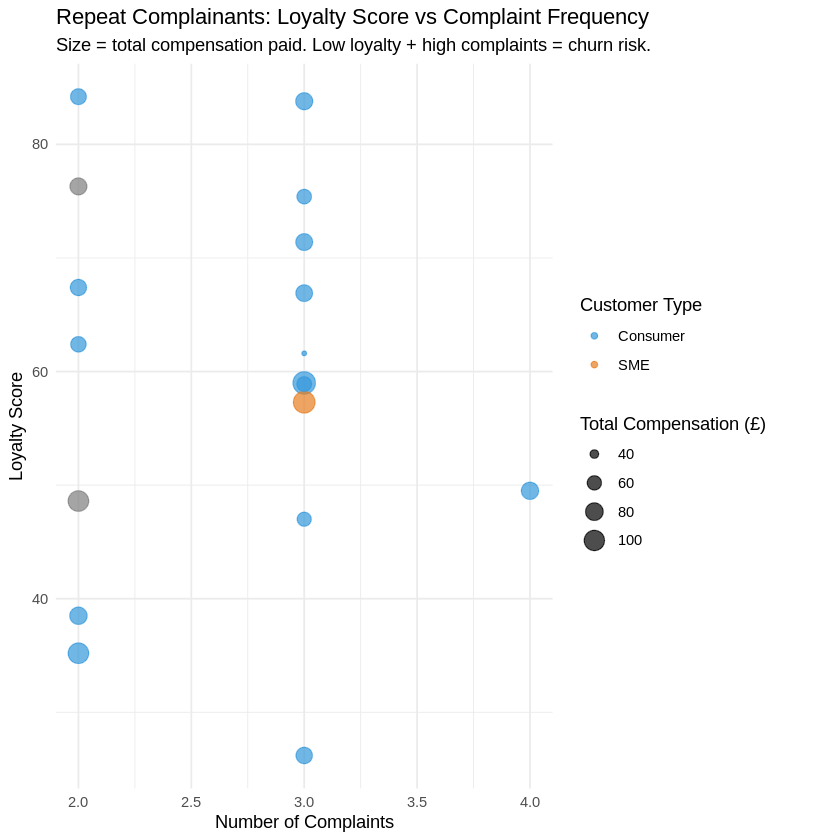

In [9]:
q7 <- sqldf("
  SELECT
    c.customer_id,
    c.home_zone,
    c.customer_type,
    c.loyalty_score,
    COUNT(cp.complaint_id)             AS complaint_count,
    ROUND(SUM(cp.compensation_amount), 2) AS total_compensation,
    GROUP_CONCAT(DISTINCT cp.complaint_type) AS complaint_types
  FROM complaints cp
  JOIN customers c ON cp.customer_id = c.customer_id
  GROUP BY c.customer_id
  HAVING complaint_count >= 2
  ORDER BY complaint_count DESC, total_compensation DESC
  LIMIT 20
")

cat("\n── Query 7: Customers with 2+ complaints ──\n")
print(q7)

ggplot(q7, aes(x = complaint_count, y = loyalty_score,
               colour = customer_type, size = total_compensation)) +
  geom_point(alpha = 0.7) +
  scale_colour_manual(values = c("Consumer" = "#3498db",
                                  "SME"      = "#e67e22",
                                  "Corporate"= "#9b59b6")) +
  labs(title = "Repeat Complainants: Loyalty Score vs Complaint Frequency",
       subtitle = "Size = total compensation paid. Low loyalty + high complaints = churn risk.",
       x = "Number of Complaints", y = "Loyalty Score",
       colour = "Customer Type", size = "Total Compensation (£)") +
  theme_minimal()

In [10]:
library(ggplot2)
library(dplyr)
library(scales)


Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


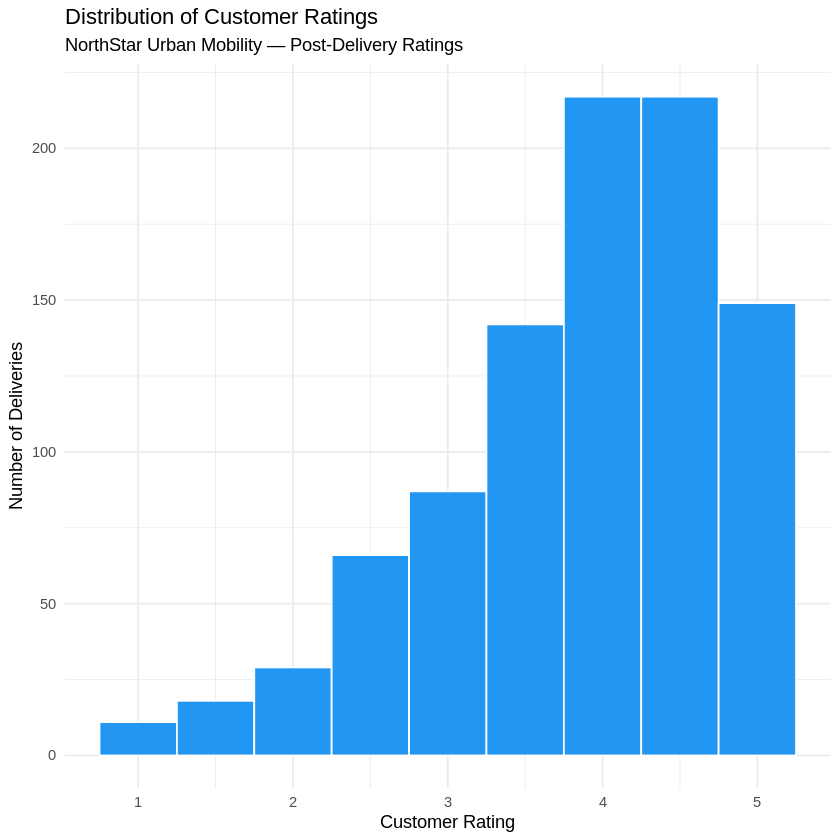

In [11]:
ggplot(deliveries, aes(x = customer_rating_post_delivery)) +
  geom_histogram(binwidth = 0.5, fill = "#2196F3", color = "white") +
  labs(
    title = "Distribution of Customer Ratings",
    subtitle = "NorthStar Urban Mobility — Post-Delivery Ratings",
    x = "Customer Rating",
    y = "Number of Deliveries"
  ) +
  theme_minimal()

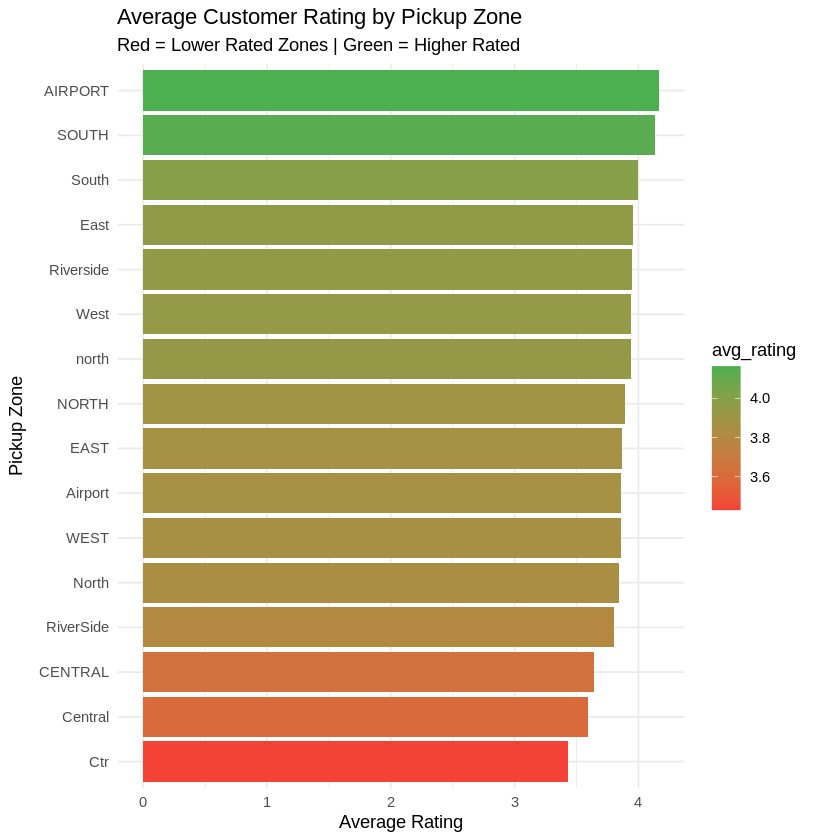

In [12]:
zone_ratings <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  group_by(pickup_zone) %>%
  summarise(avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE)) %>%
  arrange(avg_rating)

ggplot(zone_ratings, aes(x = reorder(pickup_zone, avg_rating), y = avg_rating, fill = avg_rating)) +
  geom_col() +
  scale_fill_gradient(low = "#F44336", high = "#4CAF50") +
  coord_flip() +
  labs(
    title = "Average Customer Rating by Pickup Zone",
    subtitle = "Red = Lower Rated Zones | Green = Higher Rated",
    x = "Pickup Zone",
    y = "Average Rating"
  ) +
  theme_minimal()

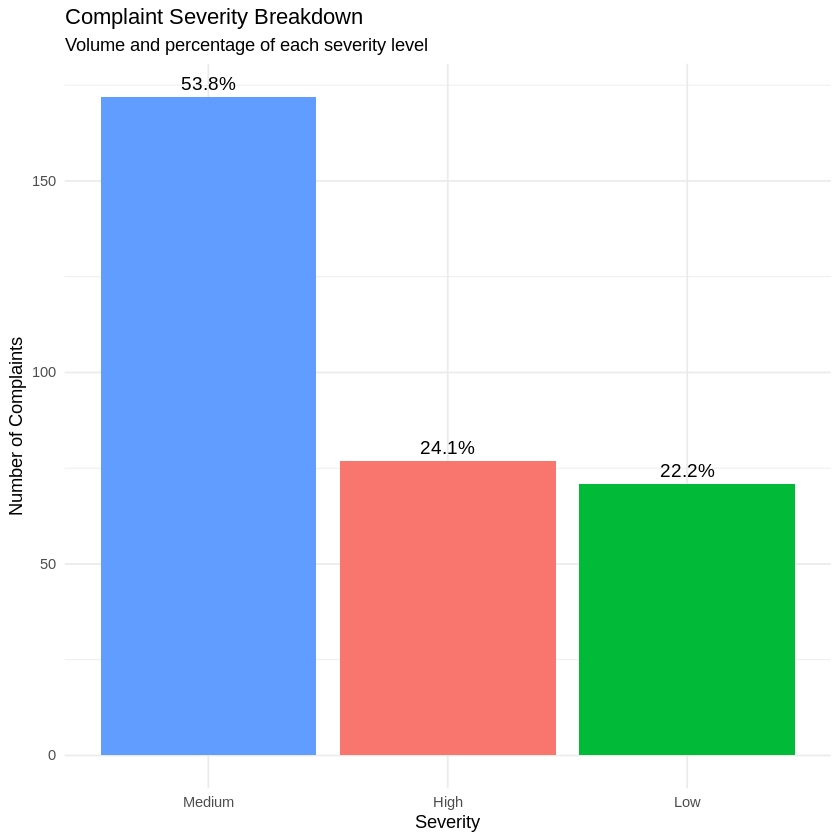

In [13]:
severity_summary <- complaints %>%
  group_by(severity) %>%
  summarise(count = n()) %>%
  mutate(pct = round(count / sum(count) * 100, 1))

ggplot(severity_summary, aes(x = reorder(severity, -count), y = count, fill = severity)) +
  geom_col() +
  geom_text(aes(label = paste0(pct, "%")), vjust = -0.5, size = 4) +
  labs(
    title = "Complaint Severity Breakdown",
    subtitle = "Volume and percentage of each severity level",
    x = "Severity",
    y = "Number of Complaints"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

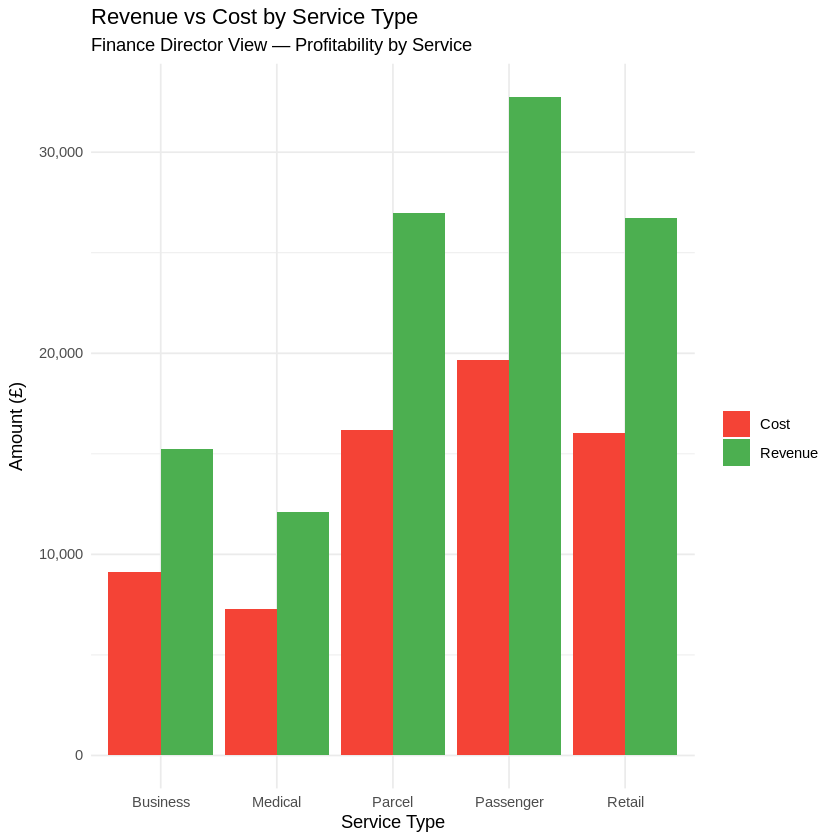

In [14]:
revenue_cost <- orders %>%
  group_by(service_type) %>%
  summarise(
    total_revenue = sum(order_value, na.rm = TRUE),
    total_cost    = sum(order_value * 0.6, na.rm = TRUE)  # assuming 60% cost ratio
  )

revenue_long <- tidyr::pivot_longer(revenue_cost,
                                     cols = c(total_revenue, total_cost),
                                     names_to = "metric",
                                     values_to = "amount")

ggplot(revenue_long, aes(x = service_type, y = amount, fill = metric)) +
  geom_col(position = "dodge") +
  scale_y_continuous(labels = comma) +
  scale_fill_manual(values = c("total_revenue" = "#4CAF50", "total_cost" = "#F44336"),
                    labels = c("Cost", "Revenue")) +
  labs(
    title = "Revenue vs Cost by Service Type",
    subtitle = "Finance Director View — Profitability by Service",
    x = "Service Type",
    y = "Amount (£)",
    fill = ""
  ) +
  theme_minimal()

Correlation between driver experience and customer rating: -0.055 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


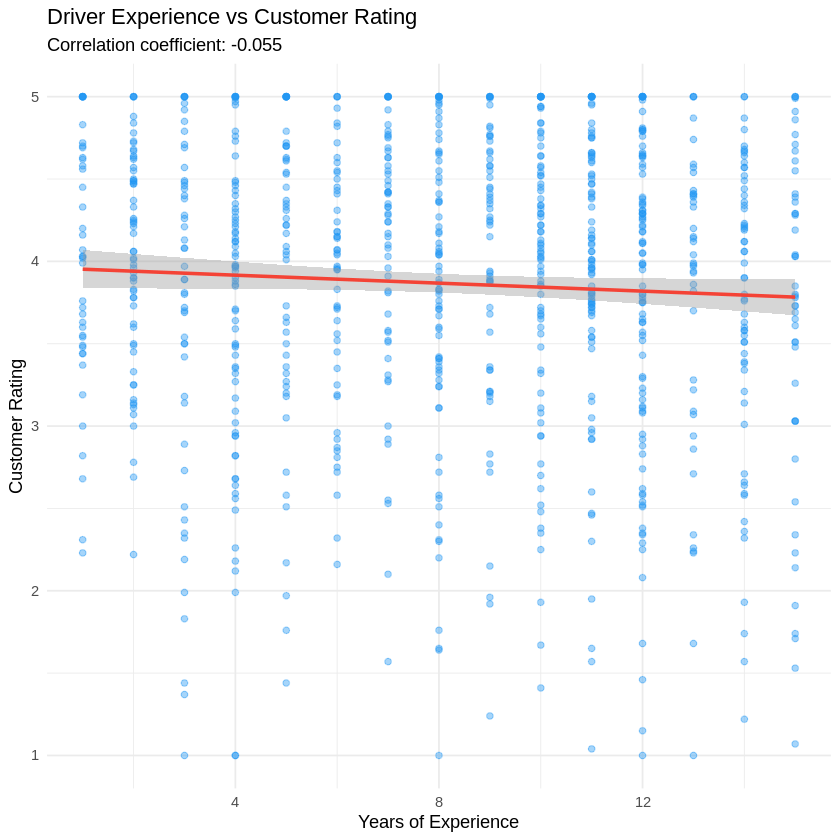

In [24]:

driver_delivery <- deliveries %>%
  left_join(drivers, by = "driver_id")

driver_delivery$years_experience <- as.numeric(driver_delivery$years_experience)
driver_delivery$customer_rating_post_delivery <- as.numeric(driver_delivery$customer_rating_post_delivery)

cor_val <- cor(driver_delivery$years_experience,
               driver_delivery$customer_rating_post_delivery,
               use = "complete.obs")

cat("Correlation between driver experience and customer rating:", round(cor_val, 3), "\n")

ggplot(driver_delivery, aes(x = years_experience, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.4, color = "#2196F3") +
  geom_smooth(method = "lm", color = "#F44336", se = TRUE) +
  labs(
    title = "Driver Experience vs Customer Rating",
    subtitle = paste("Correlation coefficient:", round(cor_val, 3)),
    x = "Years of Experience",
    y = "Customer Rating"
  ) +
  theme_minimal()